# FASE 2 — Preparação dos Dados / Feature Engineering
**Challenge 002 — Redesign de Suporte (G4 Educação)** · Autor: Thales Barbosa · 2026-07-16

Este notebook **executa e valida** o pipeline implementado em [`src/data_prep.py`](../src/data_prep.py)
(fonte única de features **e** premissas — fases 3, 5 e 6 importam o mesmo módulo). O dicionário completo
(definição, fórmula, justificativa, status, caveats) está em [`docs/feature_engineering.md`](../docs/feature_engineering.md).

O desenho desta fase passou por um **painel de revisão com 3 lentes independentes** (estatística, negócio/ROI,
avaliador do challenge) antes da implementação — decisões D-008/D-009 no `process-log/decisions.md`.

Regras herdadas da FASE 1:
- **D-005**: FRT/TTR são timestamps sintéticos → features derivadas carregam o prefixo **`synthetic_`** e não fundamentam conclusão;
- **D-006**: nulos estruturais → dtypes anuláveis, nunca imputados;
- Premissas de negócio têm **faixa low/base/high declarada** e são rotuladas `assumption` (proibidas como preditor);
- Testes unitários do pipeline e do mecanismo de SLA: [`tests/test_data_prep.py`](../tests/test_data_prep.py) (14 testes).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import (
    build_dataset1, build_dataset2, save_processed, sla_violation,
    FEATURE_STATUS, features_by_status,
    AHT_MIN_BY_CHANNEL, EFFORT_MULT_BY_TYPE, EFFORT_MULT_BY_PRIORITY,
    AGENT_COST_BRL_PER_HOUR, ANNUALIZATION_FACTOR, TICKETS_PER_YEAR,
    SLA_TARGET_HOURS_BY_PRIORITY, MIN_WORDS_D2, TOPIC_CLASSES,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
BLUE = sns.color_palette("deep")[0]
ASSETS = Path("../docs/assets")

d1 = build_dataset1()   # sanity checks estruturais rodam dentro do build
d2 = build_dataset2()
print(f"Dataset 1: {d1.shape[0]:,} linhas x {d1.shape[1]} colunas ({d1.shape[1] - 17} features novas)")
print(f"Dataset 2: {d2.shape[0]:,} linhas x {d2.shape[1]} colunas "
      f"({d2.attrs['rows_removed_short_docs']} docs com <{MIN_WORDS_D2} palavras removidos)")
print("\nStatus das features (dicionário machine-readable):")
print(pd.Series(FEATURE_STATUS).value_counts().to_string())

Dataset 1: 8,469 linhas x 40 colunas (23 features novas)
Dataset 2: 47,823 linhas x 5 colunas (14 docs com <3 palavras removidos)

Status das features (dicionário machine-readable):
measured          14
target_derived     3
synthetic_demo     3
assumption         2
demo_only          1


## 1. Dataset 1 — validação das features

### 1.1 Grupo A — flags de status, prioridade e satisfação

In [2]:
flags = ["is_closed", "is_open", "is_pending", "is_unresolved",
         "is_critical", "is_high_urgency", "is_repeat_customer"]
print(pd.DataFrame({"True": [int(d1[f].sum()) for f in flags],
                    "False": [int((~d1[f]).sum()) for f in flags]}, index=flags))
print("\nExclusividade mútua de status:", (d1[["is_closed", "is_open", "is_pending"]].sum(axis=1) == 1).all())
print("is_unresolved (backlog Open+Pending):", f"{d1['is_unresolved'].mean() * 100:.1f}% da base")
print("priority_rank:", dict(d1.groupby("Ticket Priority", observed=True)["priority_rank"].first().sort_index()))
print("\ntickets_per_customer:", d1["tickets_per_customer"].value_counts().sort_index().to_dict(),
      "(caveat: e-mails repetidos podem ser colisão do gerador sintético)")

                    True  False
is_closed           2769   5700
is_open             2819   5650
is_pending          2881   5588
is_unresolved       5700   2769
is_critical         2129   6340
is_high_urgency     4214   4255
is_repeat_customer   288   8181

Exclusividade mútua de status: True
is_unresolved (backlog Open+Pending): 67.3% da base
priority_rank: {'Low': np.int8(1), 'Medium': np.int8(2), 'High': np.int8(3), 'Critical': np.int8(4)}

tickets_per_customer: {1: 8181, 2: 262, 3: 18, 4: 8} (caveat: e-mails repetidos podem ser colisão do gerador sintético)


In [3]:
print("Derivadas do rating — target_derived (leakage se usadas para prever satisfação):\n")
print("is_rated == is_closed em 100% das linhas:", d1["is_rated"].eq(d1["is_closed"]).all(),
      " -> identidade ESTRUTURAL destes dados (documentada; em operação real podem divergir)")
print("\nis_dissatisfied:", d1["is_dissatisfied"].value_counts(dropna=False).to_dict())
print("is_satisfied:   ", d1["is_satisfied"].value_counts(dropna=False).to_dict())
print("\n<NA> em ambos =", int(d1["is_dissatisfied"].isna().sum()), "= tickets não-Closed (D-006: nunca imputar)")

Derivadas do rating — target_derived (leakage se usadas para prever satisfação):

is_rated == is_closed em 100% das linhas: True  -> identidade ESTRUTURAL destes dados (documentada; em operação real podem divergir)

is_dissatisfied: {<NA>: 5700, np.False_: 1667, np.True_: 1102}
is_satisfied:    {<NA>: 5700, np.False_: 1682, np.True_: 1087}

<NA> em ambos = 5700 = tickets não-Closed (D-006: nunca imputar)


### 1.2 Grupo B — tempo sintético (prefixo `synthetic_`, D-005)

Só 3 colunas materializadas (timestamps parseados + delta com sinal). `response_minutes` e
`total_handling_minutes` do plano **não são computáveis** (não existe timestamp de abertura) e
`sla_violation` **não é materializada** (D-009) — o mecanismo existe como função pura, demonstrado em §1.3.

In [4]:
delta = d1["synthetic_delta_resolution_minutes"]
print(f"synthetic_delta_resolution_minutes (n={delta.notna().sum():,}, NA estrutural={delta.isna().sum():,}):")
print((delta / 60).describe().round(2).rename("horas"))
neg = (delta < 0).sum()
print(f"\nNegativos: {neg:,} ({neg / delta.notna().sum() * 100:.1f}%) — bate com a auditoria (49,3%)")
print("Confirma D-005: metade das 'resoluções' ocorre ANTES da 1ª resposta -> não é duração.")

synthetic_delta_resolution_minutes (n=2,769, NA estrutural=5,700):
count    2769.00
mean       -0.06
std         9.56
min       -23.23
25%        -6.93
50%         0.17
75%         6.48
max        23.47
Name: horas, dtype: float64

Negativos: 1,365 (49.3%) — bate com a auditoria (49,3%)
Confirma D-005: metade das 'resoluções' ocorre ANTES da 1ª resposta -> não é duração.


### 1.3 Mecanismo real de SLA — função pura `sla_violation()` (D-009)

A regra de produção é `duração_observada > alvo_da_prioridade` (durações reais são ≥ 0 por construção —
sem `abs()`). Três demonstrações: (a) a função funciona sobre durações fabricadas válidas;
(b) alimentada com o delta sintético, ela **rejeita 49,3% do input como inválido** (durações negativas → `NA`);
(c) prova analítica de que qualquer taxa calculada sobre o delta seguiria a geometria triangular do gerador,
não a operação.

In [5]:
# (a) durações fabricadas válidas (mesmo contrato dos testes unitários)
demo = pd.DataFrame({
    "duração_h": [3, 5, 7, 9, 20, 50],
    "prioridade": ["Critical", "Critical", "High", "High", "Medium", "Low"],
})
demo["alvo_h"] = demo["prioridade"].map(SLA_TARGET_HOURS_BY_PRIORITY)
demo["violou_sla"] = sla_violation(demo["duração_h"] * 60.0, demo["prioridade"])
print("(a) Mecanismo sobre durações VÁLIDAS (alvos ilustrativos, ajustáveis):")
print(demo.to_string(index=False))

# (b) o mecanismo aplicado ao delta sintético rejeita o input
out = sla_violation(delta, d1["Ticket Priority"])
closed_n = delta.notna().sum()
invalid = int(delta.notna().sum() - out[delta.notna()].notna().sum())
print(f"\n(b) Sobre o delta sintético: {invalid:,} de {closed_n:,} Closed ({invalid / closed_n * 100:.1f}%) "
      "rejeitados como input INVÁLIDO (duração negativa -> <NA>).")
print("    O próprio mecanismo prova que o delta não é duração.")

# (c) prova analítica: P(delta > t) sob triangular(±24h) = (1 - t/24)^2 / 2
print("\n(c) Se alguém calculasse 'taxa de violação' assim mesmo, obteria a geometria do gerador:")
T = 24.0
for prio in ["Critical", "High", "Medium", "Low"]:
    t = SLA_TARGET_HOURS_BY_PRIORITY[prio]
    teoria = (max(0.0, 1 - t / T) ** 2) / 2
    obs = ((delta[d1["Ticket Priority"] == prio].dropna() / 60) > t).mean()  # só Closed (NaN>t seria False e diluiria o denominador)
    print(f"    {prio:<9} alvo {t:>4.0f}h | teórico triangular {teoria * 100:5.1f}% | observado {obs * 100:5.1f}%")
print("    Observado ≈ teórico -> qualquer 'insight de SLA' daqui seria artefato do sorteio, não operação.")

(a) Mecanismo sobre durações VÁLIDAS (alvos ilustrativos, ajustáveis):
 duração_h prioridade  alvo_h  violou_sla
         3   Critical     4.0       False
         5   Critical     4.0        True
         7       High     8.0       False
         9       High     8.0        True
        20     Medium    24.0       False
        50        Low    48.0        True

(b) Sobre o delta sintético: 1,365 de 2,769 Closed (49.3%) rejeitados como input INVÁLIDO (duração negativa -> <NA>).
    O próprio mecanismo prova que o delta não é duração.

(c) Se alguém calculasse 'taxa de violação' assim mesmo, obteria a geometria do gerador:
    Critical  alvo    4h | teórico triangular  34.7% | observado  32.5%
    High      alvo    8h | teórico triangular  22.2% | observado  22.4%
    Medium    alvo   24h | teórico triangular   0.0% | observado   0.0%
    Low       alvo   48h | teórico triangular   0.0% | observado   0.0%
    Observado ≈ teórico -> qualquer 'insight de SLA' daqui seria artefato do sort

**Leitura:** o observado casa com a previsão analítica da distribuição triangular (diferença de dois
horários uniformes independentes) em todas as prioridades — prova formal de que taxas de SLA sobre estes dados
descrevem o **gerador dos dados**, não a operação. Por isso a coluna não existe no parquet (D-009) e o
guardrail no dicionário proíbe agregados de SLA na FASE 3.

### 1.4 Grupo C — `est_handle_minutes` e `est_cost_brl` (status: `assumption`)

In [6]:
print("PREMISSAS DECLARADAS (fonte única em src/data_prep.py; sliders no ROI Simulator da FASE 6)")
print("Origem: premissas do autor na ordem de grandeza de benchmarks públicos de CX — sem fonte única")
print("auditável por valor; por isso cada premissa central tem faixa low/base/high p/ sensibilidade.\n")
aht = pd.DataFrame(AHT_MIN_BY_CHANNEL).T[["low", "base", "high"]]
print("Esforço de AGENTE por ticket (ciclo completo: todas as interações + after-work), em minutos:")
print(aht.to_string())
print("\nRacional da ordenação: Email 18 (multi-toque 2-3 interações) > Phone 15 (síncrono 1:1 +")
print("registro pós-chamada) ≈ Social 15 (resposta pública + DM) > Chat 10 (~15-18 min de relógio ÷")
print("concorrência de 1,5-2 sessões simultâneas por agente).")
print("\nMultiplicador por tipo:      ", EFFORT_MULT_BY_TYPE)
print("Multiplicador por prioridade:", EFFORT_MULT_BY_PRIORITY)
print("Modelo multiplicativo assume INDEPENDÊNCIA canal x tipo x prioridade (escolha declarada).")
print("\nCusto carregado do agente (R$/h):", AGENT_COST_BRL_PER_HOUR)
print(f"Fator de anualização (D-001): {TICKETS_PER_YEAR:,} / 8.469 = {ANNUALIZATION_FACTOR:.3f}")

PREMISSAS DECLARADAS (fonte única em src/data_prep.py; sliders no ROI Simulator da FASE 6)
Origem: premissas do autor na ordem de grandeza de benchmarks públicos de CX — sem fonte única
auditável por valor; por isso cada premissa central tem faixa low/base/high p/ sensibilidade.

Esforço de AGENTE por ticket (ciclo completo: todas as interações + after-work), em minutos:
               low  base  high
Email         12.0  18.0  25.0
Phone         10.0  15.0  22.0
Social media  10.0  15.0  22.0
Chat           6.0  10.0  16.0

Racional da ordenação: Email 18 (multi-toque 2-3 interações) > Phone 15 (síncrono 1:1 +
registro pós-chamada) ≈ Social 15 (resposta pública + DM) > Chat 10 (~15-18 min de relógio ÷
concorrência de 1,5-2 sessões simultâneas por agente).

Multiplicador por tipo:       {'Technical issue': 1.5, 'Refund request': 1.2, 'Cancellation request': 1.1, 'Billing inquiry': 1.0, 'Product inquiry': 0.8}
Multiplicador por prioridade: {'Low': 0.9, 'Medium': 1.0, 'High': 1.2, 'Critic

       est_handle_minutes  est_cost_brl
count             8469.00       8469.00
mean                18.41         12.28
std                  6.21          4.14
min                  7.20          4.80
25%                 14.00          9.33
50%                 17.82         11.88
75%                 21.60         14.40
max                 37.80         25.20

Base (8.469 tickets): 2,599 horas estimadas | R$ 103,961 (cenário base)
Anualizado (x3.54 -> ~30,000 tickets): 9,207 h/ano | R$ 368,263/ano
(Quantificação completa de desperdício, com sensibilidade low/high, é entregue na FASE 3.)


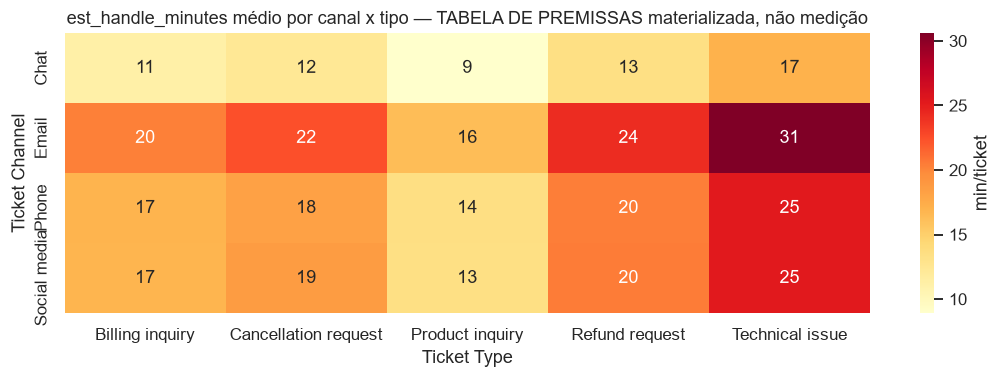

In [7]:
print(d1[["est_handle_minutes", "est_cost_brl"]].describe().round(2).to_string())
tot_h = d1["est_handle_minutes"].sum() / 60
tot_cost = d1["est_cost_brl"].sum()
print(f"\nBase (8.469 tickets): {tot_h:,.0f} horas estimadas | R$ {tot_cost:,.0f} (cenário base)")
print(f"Anualizado (x{ANNUALIZATION_FACTOR:.2f} -> ~{TICKETS_PER_YEAR:,} tickets): "
      f"{tot_h * ANNUALIZATION_FACTOR:,.0f} h/ano | R$ {tot_cost * ANNUALIZATION_FACTOR:,.0f}/ano")
print("(Quantificação completa de desperdício, com sensibilidade low/high, é entregue na FASE 3.)")

piv = d1.pivot_table(values="est_handle_minutes", index="Ticket Channel",
                     columns="Ticket Type", aggfunc="mean", observed=True).round(1)
plt.figure(figsize=(10, 3.6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "min/ticket"})
plt.title("est_handle_minutes médio por canal x tipo — TABELA DE PREMISSAS materializada, não medição")
plt.tight_layout()
plt.savefig(ASSETS / "d1_est_handle_minutes.png", bbox_inches="tight")
plt.show()

**Guardrails do Grupo C (dicionário §3):** `est_handle_minutes`/`est_cost_brl` são função
determinística de 3 categóricas com pesos-premissa — **proibidas como preditor ou em teste estatístico**
(qualquer "achado" envolvendo-as seria tautologia). Servem exclusivamente como peso contábil volume → horas → custo.

### 1.5 Grupo D — texto e cliente

In [8]:
print("description_words:", d1["description_words"].describe().round(1).to_dict())
print("resolution_words (só Closed, Int32 anulável):",
      d1["resolution_words"].dropna().describe().round(1).to_dict())
print("\nage_group (bins de largura ~igual 13/13/13/14 anos, fechados à direita):")
print(d1["age_group"].value_counts().sort_index().to_string())
print("\nPlaceholder {product_purchased} no original:",
      int(d1["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True).sum()), "de", len(d1))
print("Placeholder em description_demo:",
      int(d1["description_demo"].str.contains(r"\{product_purchased\}", regex=True).sum()))
print("\nAntes :", d1.loc[0, "Ticket Description"][:80].replace("\n", " "))
print("Depois:", d1.loc[0, "description_demo"][:80].replace("\n", " "))
print("\n(description_demo: uso EXCLUSIVO em demonstração de UI na FASE 6 — nunca em treino/avaliação de modelo.)")

description_words: {'count': 8469.0, 'mean': 46.5, 'std': 8.5, 'min': 21.0, '25%': 43.0, '50%': 49.0, '75%': 52.0, 'max': 63.0}
resolution_words (só Closed, Int32 anulável): {'count': 2769.0, 'mean': 5.5, 'std': 1.5, 'min': 3.0, '25%': 4.0, '50%': 5.0, '75%': 7.0, 'max': 8.0}

age_group (bins de largura ~igual 13/13/13/14 anos, fechados à direita):
age_group
18-30    2091
31-43    2017
44-56    2147
57-70    2214

Placeholder {product_purchased} no original: 8469 de 8469
Placeholder em description_demo: 0

Antes : I'm having an issue with the {product_purchased}. Please assist.  Your billing z
Depois: I'm having an issue with the GoPro Hero. Please assist.  Your billing zip code i

(description_demo: uso EXCLUSIVO em demonstração de UI na FASE 6 — nunca em treino/avaliação de modelo.)


## 2. Dataset 2 — validação da preparação

In [9]:
print(f"Linhas: {len(d2):,} (removidos {d2.attrs['rows_removed_short_docs']} docs com <{MIN_WORDS_D2} palavras;"
      f" tokenização: str.split() em whitespace)")
print("Removidos por classe:", d2.attrs["removed_by_class"])
print("doc_ids removidos (rastreáveis à linha do CSV bruto):", d2.attrs["removed_doc_ids"])
print("\ndoc_id atribuído ANTES do filtro -> max doc_id =", int(d2["doc_id"].max()), "(base bruta: 0..47836)")
print("\nMapeamento congelado de classes (TOPIC_CLASSES — a FASE 5 NÃO redefine):")
for i, c in enumerate(TOPIC_CLASSES):
    print(f"  {i}: {c}")
print("\nDistribuição pós-filtro:")
print(d2["Topic_group"].value_counts().to_string())

Linhas: 47,823 (removidos 14 docs com <3 palavras; tokenização: str.split() em whitespace)
Removidos por classe: {'Hardware': 6, 'HR Support': 4, 'Miscellaneous': 2, 'Access': 1, 'Purchase': 1}
doc_ids removidos (rastreáveis à linha do CSV bruto): [4215, 4635, 6450, 8799, 10596, 11612, 15528, 22172, 23348, 29681, 36283, 36619, 37497, 41988]

doc_id atribuído ANTES do filtro -> max doc_id = 47836 (base bruta: 0..47836)

Mapeamento congelado de classes (TOPIC_CLASSES — a FASE 5 NÃO redefine):
  0: Access
  1: Administrative rights
  2: HR Support
  3: Hardware
  4: Internal Project
  5: Miscellaneous
  6: Purchase
  7: Storage

Distribuição pós-filtro:
Topic_group
Hardware                 13611
HR Support               10911
Access                    7124
Miscellaneous             7058
Storage                   2777
Purchase                  2463
Internal Project          2119
Administrative rights     1760


## 3. Persistência e contrato de saída

In [10]:
paths = save_processed(d1, d2)
for k, p in paths.items():
    print(f"{k}: {p.name} ({p.stat().st_size / 1e6:.1f} MB)")

r1 = pd.read_parquet(paths["dataset1"])
r2 = pd.read_parquet(paths["dataset2"])
assert r1.shape == d1.shape and r2.shape == d2.shape
assert r1["is_dissatisfied"].dtype.name == "boolean", "boolean anulável deve sobreviver ao parquet"
assert r1["resolution_words"].dtype.name == "Int32", "Int32 anulável deve sobreviver ao parquet"
assert str(r1["Ticket Priority"].dtype) == "category" and r1["Ticket Priority"].cat.ordered
assert str(r2["Topic_group"].dtype) == "category"
print("\nRound-trip parquet OK — shapes, categorias ordenadas e dtypes anuláveis preservados")
print("(Caveat documentado: booleans anuláveis têm suporte irregular em algumas libs de viz;")
print(" a FASE 6 converte explicitamente antes de plotar.)")
print("\nDataset 1 final:", r1.shape, "| Dataset 2 final:", r2.shape)

dataset1: tickets_features.parquet (2.2 MB)
dataset2: it_tickets_clean.parquet (6.4 MB)



Round-trip parquet OK — shapes, categorias ordenadas e dtypes anuláveis preservados
(Caveat documentado: booleans anuláveis têm suporte irregular em algumas libs de viz;
 a FASE 6 converte explicitamente antes de plotar.)

Dataset 1 final: (8469, 40) | Dataset 2 final: (47823, 5)


---
## Síntese da FASE 2

| Grupo | Features | Status | Pode alimentar |
|---|---|---|---|
| A — Status/prioridade/cliente | is_closed, is_open, is_pending, **is_unresolved**, is_critical, is_high_urgency, priority_rank, tickets_per_customer, is_repeat_customer | `measured` | análises e modelos |
| A' — Derivadas do rating | is_rated (≡ is_closed nestes dados), is_dissatisfied, is_satisfied | `target_derived` | análises; **nunca** como preditor de satisfação |
| B — Tempo sintético | synthetic_first_response_ts, synthetic_resolution_ts, synthetic_delta_resolution_minutes | `synthetic_demo` | apenas demonstrações rotuladas |
| C — Premissas materializadas | est_handle_minutes, est_cost_brl | `assumption` | conversão volume→horas→custo; **nunca** preditor/teste |
| D — Texto | description_chars/words, resolution_chars/words, age_group | `measured` | análises e modelos |
| D′ — Demo de UI | description_demo | `demo_only` | **só** exibição no protótipo (FASE 6); guardrail testado |
| Dataset 2 | doc_id (pré-filtro), word_count, char_count + filtro <3 palavras + TOPIC_CLASSES congelado | `measured` | FASE 5 |

**Rastreabilidade das 7 features-exemplo do plano mestre** (tabela completa no dicionário):
is_closed ✅ · is_pending ✅ · is_critical ✅ · resolution_minutes → adaptada como `synthetic_delta_resolution_minutes` ·
response_minutes ❌ N/A (sem timestamp de abertura) · total_handling_minutes ❌ N/A (idem) ·
sla_violation → mecanismo real como função pura + demo; coluna não materializada (D-009).

Artefatos: `src/data_prep.py` · `tests/test_data_prep.py` (14 ✅) · `data/processed/*.parquet` ·
`docs/feature_engineering.md` · este notebook.